# A Machine Learning-Based Approach to Predicting Customer Subscription to Term Deposits Using Bank Marketing Data

**Course:** MATH2319 Machine Learning  
**Assessment:** Course Project Phase 1  

**Group Name:** Group_52  
**Student Name(s):** Bavya Prabhakar(s4140256), Prathibha Magesh(s3859590), Thariq Al Azeez Noorul Ameen(s4148381)

## Table of Contents

1. [Introduction](#introduction)
   
   1.1 [Dataset Source](#dataset-source)
   
   1.2 [Dataset Details](#dataset-details)
   
   1.3 [Dataset Features](#dataset-features)
   
   1.4 [Target Features](#target-features)

2. [Goals and Objectives](#goals-and-objectives)

3. [Data Cleaning and Preprocessing](#data-cleaning-and-preprocessing)
   
   3.1 [Handling Missing Values](#handling-missing)
   
   3.2 [Category Standardisation](#category-standardisation)
   
   3.3 [Data Validation](#data-validation)

4. [Data Exploration and Visualisation](#data-exploration-and-visualisation)

   4.1 [Target Variable Analysis](#Target-variable)

   4.2 [One Variable Analysis](#one-variable)
   
   4.3 [Two Variable Analysis](#two-variable)
   
   4.4 [Three Variable Analysis](#three-variable)

6. [Summary and Conclusion](#summary-and-conclusion)

7. [Next Steps (Phase 2)](#next-steps)

8. [Literature Review](#literature-review)

9. [References](#references)

<a id="introduction"></a>
# 1. Introduction

<a id="dataset-source"></a>
## 1.1 Dataset Source

The dataset used in this project is the **Bank Marketing dataset**, which is publicly available from the **UCI Machine Learning Repository**. It is derived from direct marketing campaigns conducted by a Portuguese banking institution, where the objective was to determine whether a customer would subscribe to a term deposit. The dataset has been widely used in machine learning research for classification tasks because it contains a combination of customer demographics, financial information, campaign-related attributes, and macroeconomic indicators.

This dataset is well suited to the objectives of the present project because it represents a realistic business problem with clear practical relevance. Predicting whether a customer is likely to subscribe can help financial institutions improve campaign efficiency, allocate marketing resources more effectively, and support more targeted customer engagement strategies.

<a id="dataset-details"></a>
## 1.2 Dataset Details

The dataset used in this project contains **4,119 observations** and **21 features**. Each observation represents an individual customer, while each feature captures a particular aspect of the customer’s profile, financial status, previous campaign interactions, or broader economic conditions. Together, these variables provide a comprehensive basis for analysing customer behaviour and identifying patterns associated with term deposit subscription.

The dataset includes the following features:

- **age:** Age of the customer (in years)  
- **job:** Occupation category of the customer  
- **marital:** Marital status of the customer  
- **education:** Education level of the customer  
- **default:** Indicates whether the customer has credit in default  
- **housing:** Indicates whether the customer has a housing loan  
- **loan:** Indicates whether the customer has a personal loan  
- **contact:** Communication method used to contact the customer  
- **month:** Month of the last contact  
- **day_of_week:** Day of the week of the last contact  
- **duration:** Duration of the last contact (in seconds)  
- **campaign:** Number of contacts performed during the current campaign  
- **pdays:** Number of days since the customer was last contacted in a previous campaign  
- **previous:** Number of contacts performed before the current campaign  
- **poutcome:** Outcome of the previous marketing campaign  
- **emp_var_rate:** Employment variation rate (economic indicator)  
- **cons_price_idx:** Consumer price index (economic indicator)  
- **cons_conf_idx:** Consumer confidence index (economic indicator)  
- **euribor3m:** Euribor 3-month interest rate  
- **nr_employed:** Number of employees (economic indicator)  
- **y:** Target feature indicating whether the customer subscribed to a term deposit (`yes` or `no`)  

Overall, the dataset contains a mix of numerical and categorical variables, making it suitable for a supervised machine learning classification problem. Its structure enables analysis of both individual customer characteristics and campaign-related factors that may influence subscription decisions.

To provide an overview of the dataset structure and the type of values contained in each feature, a sample of 10 randomly selected observations is presented below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import warnings

sns.set(style="whitegrid")
# display all columns
pd.set_option('display.max_columns', None)
# decimal point set as 3
pd.options.display.float_format = '{:.3f}'.format


In [2]:
# read the csv file
df = pd.read_csv("Phase1_Group 52.csv", sep=';')

In [3]:
#randomly select 10 rows
df.sample(10, random_state=999)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
3792,32,technician,single,professional.course,no,yes,no,cellular,may,wed,97,2,999,0,nonexistent,-1.800,92.893,-46.200,1.334,5099.100,no
2146,37,admin.,married,professional.course,unknown,yes,no,cellular,nov,wed,37,1,999,0,nonexistent,-0.100,93.200,-42.000,4.120,5195.800,no
1171,38,blue-collar,divorced,unknown,no,no,no,telephone,jun,fri,278,1,999,0,nonexistent,1.400,94.465,-41.800,4.967,5228.100,no
4033,49,admin.,married,basic.9y,unknown,no,yes,cellular,aug,thu,86,3,999,0,nonexistent,1.400,93.444,-36.100,4.968,5228.100,no
565,34,blue-collar,married,professional.course,no,yes,no,cellular,nov,tue,135,3,999,0,nonexistent,-0.100,93.200,-42.000,4.153,5195.800,no
3471,46,management,married,university.degree,no,no,no,telephone,may,mon,103,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
2737,59,housemaid,married,basic.4y,unknown,no,no,cellular,aug,tue,77,6,999,0,nonexistent,1.400,93.444,-36.100,4.965,5228.100,no
4089,25,admin.,single,university.degree,no,yes,yes,cellular,oct,fri,115,1,999,1,failure,-3.400,92.431,-26.900,0.739,5017.500,yes
749,36,technician,single,high.school,no,yes,no,cellular,jul,wed,243,1,999,1,failure,-2.900,92.469,-33.600,1.029,5076.200,no
1150,41,entrepreneur,married,basic.4y,no,yes,no,telephone,jul,fri,89,2,999,0,nonexistent,1.400,93.918,-42.700,4.959,5228.100,no


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (4119, 21)


<a id= "dataset-features"></a>
## 1.3 Dataset Features


The following table summarises the descriptive features included in this project. Only the input features used for analysis and subsequent modelling are presented. The target feature `y` is excluded from this table and is discussed separately in Section 1.4.

| Feature | Data type | Units | Brief description |
|---|---|---|---|
| age | Numeric | Years | Age of the customer |
| job | Nominal categorical | NA | Type of occupation of the customer |
| marital | Nominal categorical | NA | Marital status of the customer |
| education | Ordinal categorical | NA | Education level of the customer |
| default | Binary categorical | NA | Indicates whether the customer has credit in default |
| housing | Binary categorical | NA | Indicates whether the customer has a housing loan |
| loan | Binary categorical | NA | Indicates whether the customer has a personal loan |
| contact | Nominal categorical | NA | Communication method used to contact the customer |
| month | Ordinal categorical | NA | Month of the last contact |
| day_of_week | Ordinal categorical | NA | Day of the week of the last contact |
| duration | Numeric | Seconds | Duration of the last contact call |
| campaign | Numeric | Count | Number of contacts performed during the current campaign for this customer |
| pdays | Numeric | Days | Number of days since the customer was last contacted in a previous campaign |
| previous | Numeric | Count | Number of contacts performed before the current campaign |
| poutcome | Nominal categorical | NA | Outcome of the previous marketing campaign |
| emp.var.rate | Numeric | Index | Employment variation rate (economic indicator) |
| cons.price.idx | Numeric | Index | Consumer price index (economic indicator) |
| cons.conf.idx | Numeric | Index | Consumer confidence index (economic indicator) |
| euribor3m | Numeric | Interest rate | Euribor 3-month interest rate |
| nr.employed | Numeric | Persons | Number of employees (economic indicator) |

Overall, the dataset consists of a combination of numerical and categorical features representing customer demographics, financial status, marketing interactions, and macroeconomic indicators. This diverse feature set provides a strong foundation for building a supervised machine learning model to predict customer subscription behaviour.

In [5]:
#Check for data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

The dataset contains a mix of numerical (`int64`, `float64`) and categorical (`object`) features.


In [6]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Number of Numerical Features :', len(num_features))

Number of Numerical Features : 21


In [7]:
##categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))


Num of Categorical Features : 0


In [8]:
df[cat_features].columns

Index([], dtype='str')

In [9]:
# filter for discrete ones (with 25 or fewer unique values)
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]

#check for discrete features
print('Num of Discrete Features:', len(discrete_features))
print('Discrete Features:', discrete_features)


Num of Discrete Features: 16
Discrete Features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'nr.employed', 'y']


In [10]:
#check for continuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))
print(continuous_features)

Num of Continuous Features : 5
['age', 'duration', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']



- To better understand the dataset, the features were first divided into numerical and categorical types based on their data type. The analysis shows that the dataset contains 10 numerical features and 11 categorical features.

- The categorical features include variables such as job, marital status, education, contact type, and previous campaign outcome. These features represent descriptive information about the customer and their interaction with the marketing campaign.

- Next, the numerical features were further classified into discrete and continuous variables. Discrete features are those with a limited number of unique values, while continuous features can take a wider range of values.

- From the analysis, 5 numerical features were identified as discrete (campaign, pdays, previous, emp.var.rate, and nr.employed), while the remaining 5 features (age, duration, cons.price.idx, cons.conf.idx, and euribor3m) were classified as continuous.

- This classification helps in selecting appropriate analysis techniques and preparing the data for further modelling.

<a id= "target-features"></a>
## 1.4 Target Features

In [11]:
# Identify target feature
print("Target Features:", 'y')

# Check unique values
print("\nUnique values in target:")
print(df['y'].value_counts())

# Check data type
print("\nData type of target:")
print(df['y'].dtype)

Target Features: y

Unique values in target:
y
no     3668
yes     451
Name: count, dtype: int64

Data type of target:
str


The target feature for this project is `y`, which indicates whether a customer subscribed to a term deposit. It is a categorical variable with two possible values, `yes` and `no`, so the problem is treated as a binary classification task. The results also show that the target variable is imbalanced, with more non-subscribers than subscribers, which is important to consider in later modelling.

<a id="goals-and-objectives"></a>
# 2. Goals and Objectives

The main goal of this project is to analyse the bank marketing dataset in order to understand the factors that influence whether a customer subscribes to a term deposit. By exploring customer demographics, financial attributes, campaign-related information, and economic indicators, the project aims to identify meaningful patterns associated with successful subscription outcomes.

The objectives of Phase 1 are to prepare the dataset for machine learning and to develop a clear understanding of its structure, quality, and underlying relationships. This includes performing appropriate data cleaning and preprocessing, examining the characteristics of individual features, and conducting exploratory data analysis through visualisation and summary statistics.

A further objective is to assess which variables appear to be more informative for prediction and to identify any issues that may affect later modelling, such as class imbalance, rare categories, or features with limited practical usability. These insights will help guide feature selection and modelling decisions in Phase 2.

From a practical perspective, this project is relevant because accurate prediction of customer subscription behaviour can support more effective marketing strategies. Financial institutions can use such insights to improve customer targeting, reduce inefficient campaign efforts, and make more informed business decisions based on data-driven evidence.

<a id= "data-cleaning-and-preprocessing"></a>
# 3. Data Cleaning and Preprocessing

<a id="handling-missing"></a>
## 3.1 Handling Missing Values

In [12]:
# Check actual missing values (NaN)
print("\n Missing Values ")
missing_na = df.isnull().sum()
display(missing_na)



 Missing Values 


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

An initial check was conducted to identify missing values (NaN) across all features. The results show that there are no missing values present in the dataset. This indicates that the dataset is complete and does not require any imputation techniques.

However, the dataset contains several entries labelled as "unknown", which can be treated as a form of missing or incomplete information. A count of these values was performed across all columns. It was observed that variables such as **default**, **education**, **housing**, and **loan** contain a noticeable number of "unknown" entries.

To maintain consistency and clarity in the dataset, all "unknown" values were replaced with **"not_specified"**. This allows the model to treat them as a separate valid category instead of ignoring or misinterpreting them. 

In [13]:
# Check 'unknown' values
print("\n Count of 'unknown' values ")
unknown_counts = {}
for col in df.columns:
    unknown_counts[col] = (df[col] == 'unknown').sum()
unknown_df = pd.DataFrame.from_dict(
    unknown_counts, 
    orient='index', 
    columns=['unknown_count']
)
display(unknown_df)


 Count of 'unknown' values 


,unknown_count
age,0
job,39
marital,11
education,167
default,803
housing,105
loan,105
contact,0
month,0
day_of_week,0


In [14]:
# Combine both into one summary 
missing_summary = pd.DataFrame({
    'NaN_count': df.isnull().sum(),
    'unknown_count': [ (df[col] == 'unknown').sum() for col in df.columns ]
})
missing_summary['total_missing_like'] = (
    missing_summary['NaN_count'] + missing_summary['unknown_count']
)
missing_summary['percentage'] = (
    missing_summary['total_missing_like'] / len(df) * 100
).round(2)
print("\n Combined Missing Summary")
display(missing_summary.sort_values(by='total_missing_like', ascending=False))



 Combined Missing Summary


,NaN_count,unknown_count,total_missing_like,percentage
default,0,803,803,19.500
education,0,167,167,4.050
housing,0,105,105,2.550
loan,0,105,105,2.550
job,0,39,39,0.950
marital,0,11,11,0.270
age,0,0,0,0.000
contact,0,0,0,0.000
month,0,0,0,0.000
day_of_week,0,0,0,0.000


In [15]:
df = df.replace('unknown', 'not_specified')

The dataset does not contain standard missing values (NaN). However, several categorical features include the placeholder value `unknown`, which represents missing or unavailable information. 

These values were retained but relabelled as `not_specified` to improve interpretability while preserving the underlying information rather than discarding it.

In [16]:
# CHECK DUPLICATES

duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

# If duplicates existed, we could remove them.
# Here they do not, but keeping the logic visible is good practice.
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("New shape after dropping duplicates:", df.shape)


Duplicate rows: 0


A check for duplicate rows was performed to ensure data uniqueness. The results show that there are **no duplicate records** in the dataset. Therefore, no rows were removed.

In [17]:
#check for unique values in each columns
unique_counts = df.nunique()
# Get a list of columns where unique counts are 1 or 1470
cols_to_drop = [col for col, count in unique_counts.items() if count in (1, 1470)]
# Print the names of columns that satisfy the condition
print("Columns to be dropped:", cols_to_drop)

Columns to be dropped: []


Each feature was analysed to identify columns with little or no variation. Columns with only a single unique value across all observations do not provide useful information for analysis or modelling.

Based on this check, no such constant columns were found in the dataset after preprocessing. Therefore, all remaining features were retained for further analysis.

In [18]:
df.describe() 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000,4119.000
mean,40.114,256.788,2.537,960.422,0.190,0.085,93.580,-40.499,3.621,5166.482
std,10.313,254.704,2.568,191.923,0.542,1.563,0.579,4.595,1.734,73.668
min,18.000,0.000,1.000,0.000,0.000,-3.400,92.201,-50.800,0.635,4963.600
25%,32.000,103.000,1.000,999.000,0.000,-1.800,93.075,-42.700,1.334,5099.100
50%,38.000,181.000,2.000,999.000,0.000,1.100,93.749,-41.800,4.857,5191.000
75%,47.000,317.000,3.000,999.000,0.000,1.400,93.994,-36.400,4.961,5228.100
max,88.000,3643.000,35.000,999.000,6.000,1.400,94.767,-26.900,5.045,5228.100


Descriptive statistics were generated for all numerical features to understand their distribution and scale. 

Key observations include:
- The average customer age is around **40 years**, with values ranging from young adults to older individuals.
- Call duration shows high variability, with some calls lasting significantly longer than others, indicating potential differences in customer engagement.
- The number of campaign contacts is generally low, with most customers being contacted only a few times.
- Economic indicators such as **employment variation rate**, **consumer price index**, and **Euribor rate** show relatively stable ranges.

These insights confirm that the dataset is clean, consistent, and ready for exploratory analysis and modelling in the next stage.

<a id="category-standardisation"></a>
## 3.2 Category Standardisation

Certain categorical values were standardised to improve consistency and reduce sparsity in the dataset. 

- The category `illiterate` in the `education` feature was merged into `other` due to its very low frequency, ensuring better representation and avoiding sparsity issues during modelling.
- Missing-like values represented as `unknown` were retained but later relabelled as `not_specified` to clearly distinguish them from valid categories while preserving information.

Importantly, no transformations were applied that would alter the true meaning of the data (e.g., merging distinct outcome categories), ensuring the integrity of the dataset is maintained for subsequent analysis.

In [19]:
# STANDARDISE COLUMN NAMES
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace('.', '_', regex=False)
)

print("\n COLUMN NAMES AFTER STANDARDISATION ")
print(df.columns.tolist())


 COLUMN NAMES AFTER STANDARDISATION 
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']


In [20]:
# CLEAN CATEGORICAL VALUES
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# Remove spaces and convert to lowercase
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

# Standardise text formatting
df['job'] = df['job'].str.replace('.', '', regex=False)
df['job'] = df['job'].str.replace('-', '_', regex=False)

df['education'] = df['education'].str.replace('.', '_', regex=False)

# Replace 'unknown' with clearer wording
df = df.replace('unknown', 'not_specified')

# Improve category readability
df['poutcome'] = df['poutcome'].replace({
    'nonexistent': 'no_previous_contact'
})

# Handle extremely rare category
df['education'] = df['education'].replace({
    'illiterate': 'other'
})


In [21]:
# RENAME SELECTED COLUMNS FOR READABILITY
df = df.rename(columns={
    'emp_var_rate': 'employment_variation_rate',
    'cons_price_idx': 'consumer_price_index',
    'cons_conf_idx': 'consumer_confidence_index',
    'euribor3m': 'euribor_3m_rate',
    'nr_employed': 'num_employed'
})

print("\n SHAPE AFTER CLEANING ")
print(df.shape)

print("\n CLEANED DATA PREVIEW ")
display(df.head())


 SHAPE AFTER CLEANING 
(4119, 21)

 CLEANED DATA PREVIEW 


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,num_employed,y
0,30,blue_collar,married,basic_9y,no,yes,no,cellular,may,fri,487,2,999,0,no_previous_contact,-1.800,92.893,-46.200,1.313,5099.100,no
1,39,services,single,high_school,no,no,no,telephone,may,fri,346,4,999,0,no_previous_contact,1.100,93.994,-36.400,4.855,5191.000,no
2,25,services,married,high_school,no,yes,no,telephone,jun,wed,227,1,999,0,no_previous_contact,1.400,94.465,-41.800,4.962,5228.100,no
3,38,services,married,basic_9y,no,not_specified,not_specified,telephone,jun,fri,17,3,999,0,no_previous_contact,1.400,94.465,-41.800,4.959,5228.100,no
4,47,admin,married,university_degree,no,yes,no,cellular,nov,mon,58,1,999,0,no_previous_contact,-0.100,93.200,-42.000,4.191,5195.800,no


In [22]:
# FINAL CATEGORY CHECK
print("\n CLEANED CATEGORICAL VALUE COUNTS ")
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()



 CLEANED CATEGORICAL VALUE COUNTS 

job:
job
admin            1012
blue_collar       884
technician        691
services          393
management        324
retired           166
self_employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
not_specified      39
Name: count, dtype: int64

marital:
marital
married          2509
single           1153
divorced          446
not_specified      11
Name: count, dtype: int64

education:
education
university_degree      1264
high_school             921
basic_9y                574
professional_course     535
basic_4y                429
basic_6y                228
not_specified           167
other                     1
Name: count, dtype: int64

default:
default
no               3315
not_specified     803
yes                 1
Name: count, dtype: int64

housing:
housing
yes              2175
no               1839
not_specified     105
Name: count, dtype: int64

loan:
loan
no               3349
yes   

In [23]:
# 10. TARGET DISTRIBUTION CHECK
print("\n TARGET DISTRIBUTION ")
target_counts = df['y'].value_counts()
target_percent = df['y'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'count': target_counts,
    'percentage': target_percent.round(2)
})
display(target_summary)


 TARGET DISTRIBUTION 


,count,percentage
y,,
no,3668,89.050
yes,451,10.950


<a id="data-validation"></a>
 ## 3.3 Data Validation 

In [24]:
# explicit checks for suspicious values
print("\n VALIDITY CHECKS ")
print("Negative age values:", (df['age'] < 0).sum())
print("Maximum age:", df['age'].max())
print("Minimum age:", df['age'].min())
print("Negative duration values:", (df['duration'] < 0).sum())
print("Negative campaign values:", (df['campaign'] < 0).sum())
print("Negative previous values:", (df['previous'] < 0).sum())


 VALIDITY CHECKS 
Negative age values: 0
Maximum age: 88
Minimum age: 18
Negative duration values: 0
Negative campaign values: 0
Negative previous values: 0


Additionally, the range of values for key variables was examined to ensure they fall within reasonable bounds. The observed values are within realistic limits, further confirming the quality and consistency of the dataset.

Overall, no anomalies or inconsistencies were detected in the examined features, indicating that the dataset is reliable and suitable for further analysis and modelling.

### Summary of Preprocessing Steps

| Issue | Feature(s) | Action Taken | Justification |
|---|---|---|---|
| Missing-like values | Multiple categorical features | `unknown` → `not_specified` | Improve clarity while preserving information |
| Rare category | education | `illiterate` → `other` | Reduce sparsity due to very low frequency |
| Duplicate records | All | Checked, none removed | No duplicates found |
| Invalid values | All | Checked | No unrealistic values detected |
| Column formatting | All | Standardised naming | Improve readability and consistency |



The dataset was carefully prepared through a series of cleaning, preprocessing, and validation steps to ensure accuracy, consistency, and reliability. Missing values were examined using both standard checks and placeholder values such as `unknown`, which were relabelled as `not_specified` to improve interpretability while preserving information.

Feature relevance was also considered during preprocessing, particularly for variables such as `duration`, which, although highly predictive, may not be available at the time of prediction in real-world scenarios. This highlights the importance of considering both predictive performance and practical applicability.

The dataset was further validated by checking for duplicate records and examining numerical features for unrealistic values. No duplicates were found, and all numerical variables were confirmed to contain valid, non-negative values within reasonable ranges. These checks indicate that the dataset is consistent and free from major data quality issues.

In addition, categorical variables were standardised to remove inconsistencies in formatting, and column names were cleaned and simplified to improve readability. Some features were also renamed to enhance clarity during analysis.

Overall, these preprocessing and validation steps ensure that the dataset is clean, well-structured, and suitable for subsequent exploratory analysis and machine learning modelling.

<a id="data-exploration-and-visualisation"></a>
# 4. Data Exploration and Visualization

<a id= "Target-variable"></a>
## 4.1 Target Variable Analysis

The distribution of the target variable indicates a clear imbalance between the two classes, with non-subscription outcomes significantly outnumbering successful subscriptions. 

This imbalance is important as it may bias predictive models towards the majority class. Therefore, appropriate evaluation metrics such as precision, recall, and F1-score will need to be considered in Phase 2 to ensure balanced model performance.

The proportion-based representation further confirms that the dataset is skewed towards the non-subscription class, reinforcing the need to account for class imbalance during modelling.

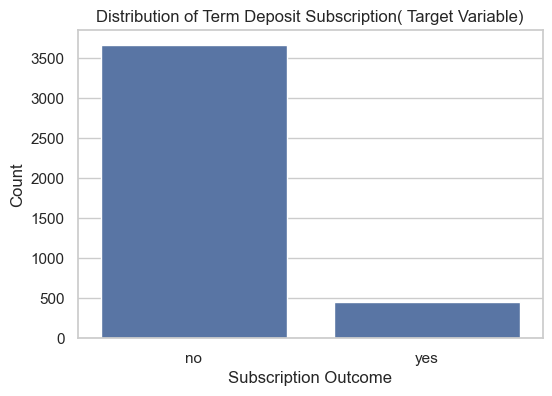

In [25]:
# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df)
plt.title("Distribution of Term Deposit Subscription( Target Variable)")
plt.xlabel("Subscription Outcome")
plt.ylabel("Count")
plt.show()

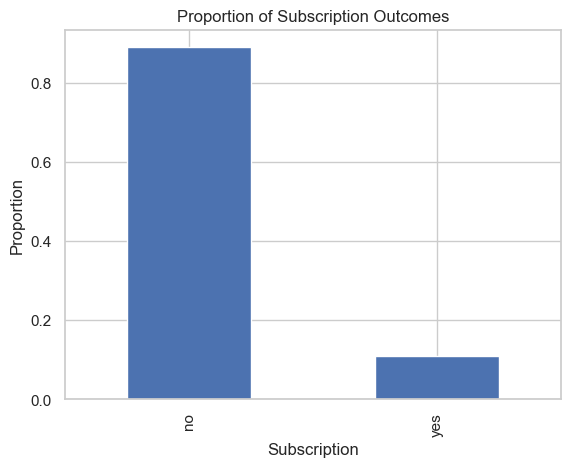

In [26]:
subscription_rate = df['y'].value_counts(normalize=True)

subscription_rate.plot(kind='bar')
plt.title("Proportion of Subscription Outcomes")
plt.ylabel("Proportion")
plt.xlabel("Subscription")
plt.show()

From the dataset, it is clear that a large majority of customers did not subscribe. Out of the total observations, approximately **3668 customers did not subscribe**, while only **451 customers subscribed**.

This shows that the dataset is **highly imbalanced**, with significantly more negative outcomes (“no”) than positive outcomes (“yes”). Such imbalance can affect model performance, as models may become biased toward predicting the majority class.

This imbalance will be considered in later stages of the project (Phase 2), where appropriate techniques may be applied to improve model performance.

<a id= "one-variable"></a>
# 4.2 One Variable Analysis

### Age Distribution


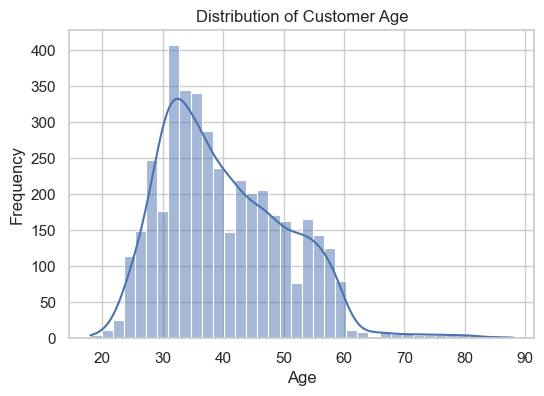

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The distribution of age appears slightly right-skewed, with a higher concentration of customers in the middle age range. This indicates that the dataset is primarily composed of working-age individuals. The presence of older customers in smaller proportions may suggest varying financial needs and behaviours across age groups, which could influence subscription likelihood.

### Duration Distribution

The distribution of call duration is highly right-skewed, with most interactions being relatively short and a small number of calls having significantly longer durations. This suggests that while most customer interactions are brief, extended conversations occur less frequently.

The skewness indicates the presence of extreme values, which may have a strong influence on model performance. Additionally, since duration reflects post-contact information, its role in predictive modelling must be carefully considered despite its potential predictive strength.

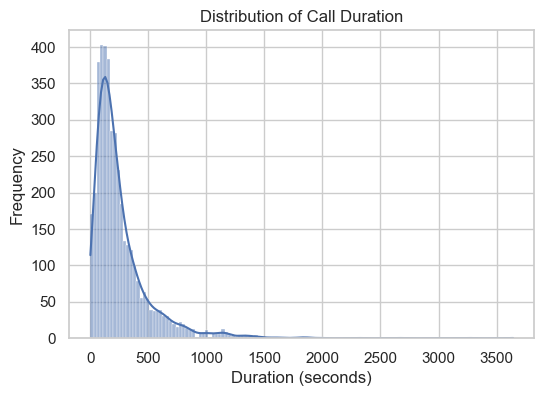

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df['duration'], kde=True)

plt.title("Distribution of Call Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

### Job Distribution 


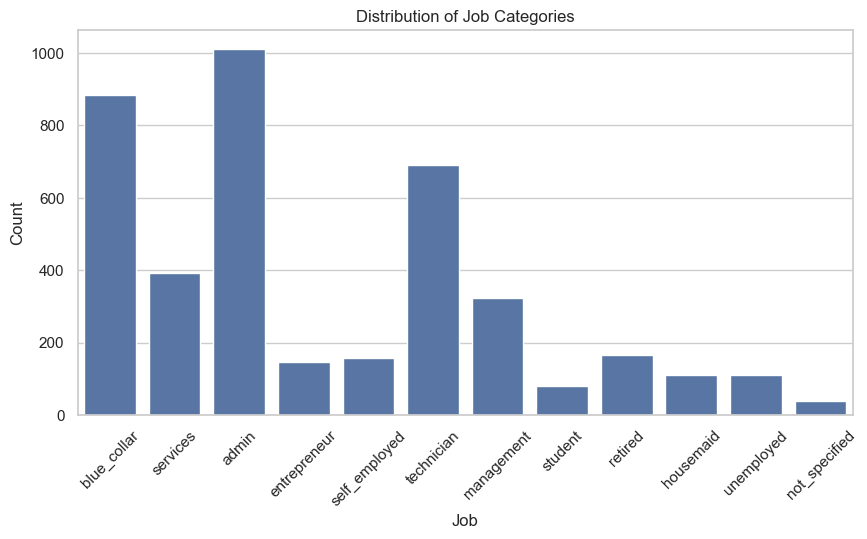

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', data=df)

plt.title("Distribution of Job Categories")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The distribution of job categories shows that certain occupations, such as administrative and blue-collar roles, are more prevalent in the dataset. This indicates that the dataset is not evenly distributed across job types, which may influence overall subscription patterns.

The dominance of specific job categories suggests that occupation could play a role in financial decision-making and should be further explored in relation to the target variable.

### Education Distribution

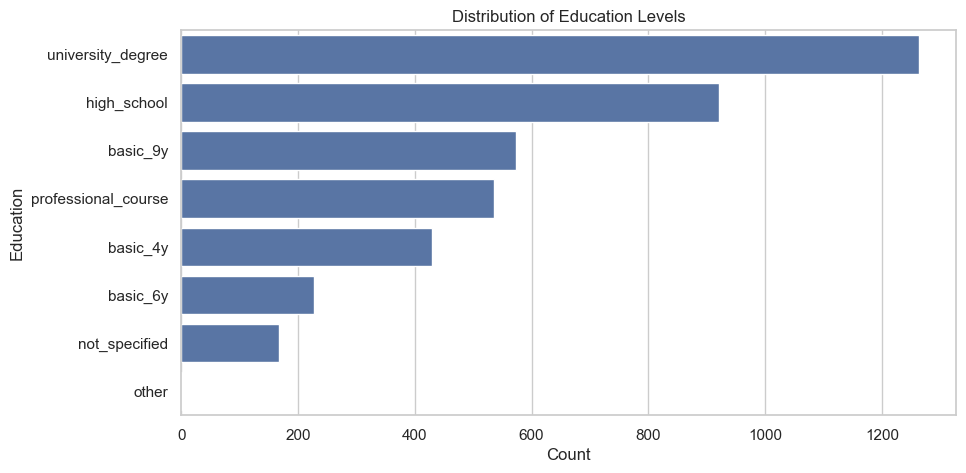

In [30]:
# 12.4 Education distribution

plt.figure(figsize=(10, 5))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.title("Distribution of Education Levels")
plt.xlabel("Count")
plt.ylabel("Education")
plt.show()

- The education distribution shows that most customers have a university degree, followed by high school education.
- Lower education levels such as basic_4y and basic_6y have fewer customers, indicating an uneven distribution.
- This suggests the dataset is more focused on moderately to highly educated individuals, which may influence subscription patterns.

<a id= "two-variable"></a>
## 4.3 Two Variable Analysis

### Job Type vs Subscription Outcome

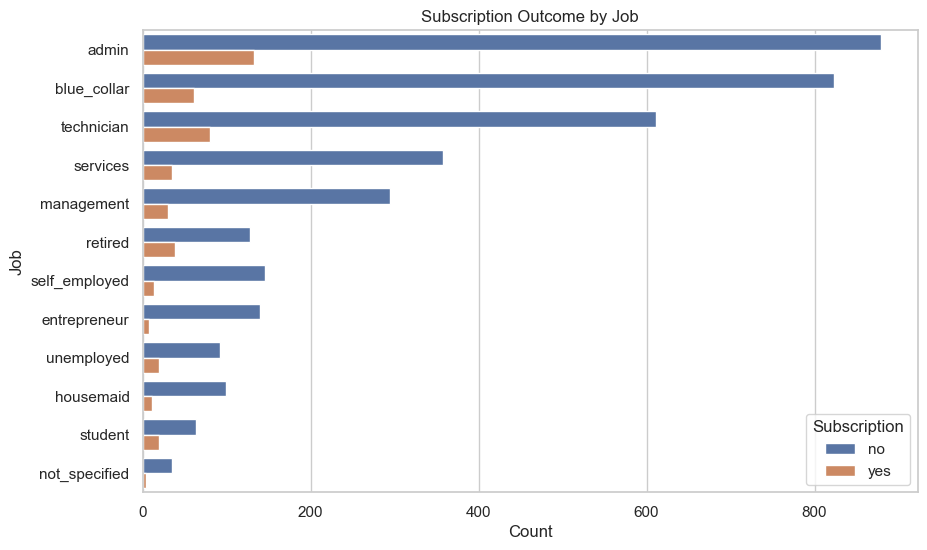

In [31]:
# 13. BIVARIATE VISUALISATIONS

# 13.1 Job vs subscription
plt.figure(figsize=(10, 6))

sns.countplot(y='job', hue='y', data=df, order=df['job'].value_counts().index)

plt.title("Subscription Outcome by Job")
plt.xlabel("Count")
plt.ylabel("Job")
plt.legend(title="Subscription")
plt.show()

- Across all job types, most customers did not subscribe, showing a clear imbalance in the outcome.
- Jobs like admin, technician, and blue-collar have higher subscriptions simply because they have more customers overall.
- There is no strong evidence that a specific job category alone significantly increases the chance of subscription.

### Contact Type vs Subscription

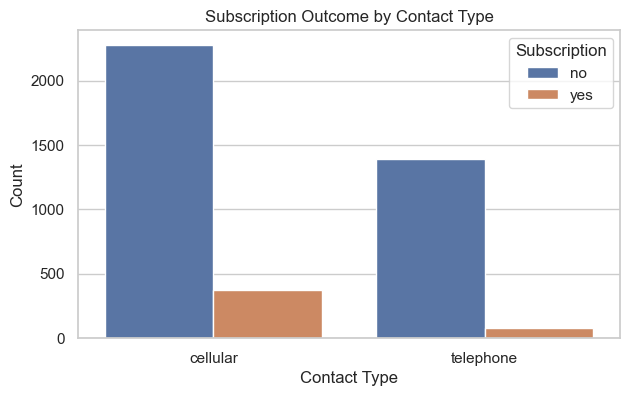

In [32]:
# 13.2 Contact type vs subscription
plt.figure(figsize=(7, 4))
sns.countplot(x='contact', hue='y', data=df)
plt.title("Subscription Outcome by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Count")
plt.legend(title="Subscription")
plt.show()


- Most customers were contacted through cellular, and this method also shows a higher number of successful subscriptions.
- Telephone contacts have significantly fewer successful outcomes compared to cellular.
- This suggests that contacting customers via cellular may be more effective in achieving subscriptions.

### Contact Month vs Subscription

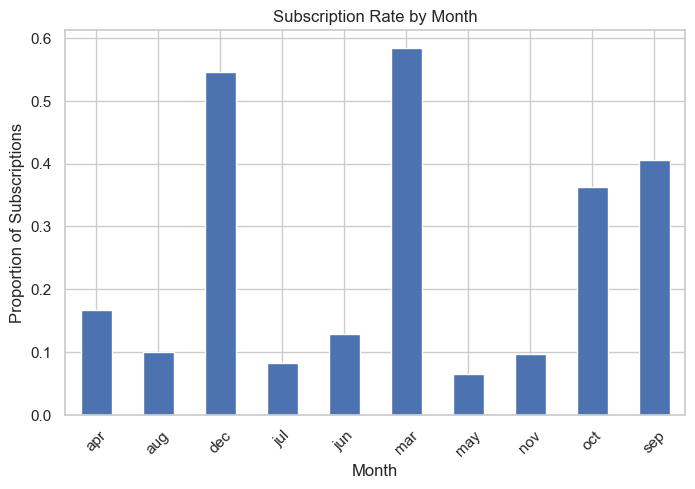

In [33]:
month_rate = df.groupby('month')['y'].value_counts(normalize=True).unstack()

plt.figure(figsize=(8,5))
month_rate['yes'].plot(kind='bar')

plt.title("Subscription Rate by Month")
plt.ylabel("Proportion of Subscriptions")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

The subscription rate varies across different months, suggesting that timing plays a role in customer decision-making. Certain months show higher success rates, which may be influenced by seasonal trends, economic conditions, or campaign timing.

This indicates that the effectiveness of marketing efforts may depend not only on customer characteristics but also on when the interaction occurs.

###  Call Duration vs Subscription

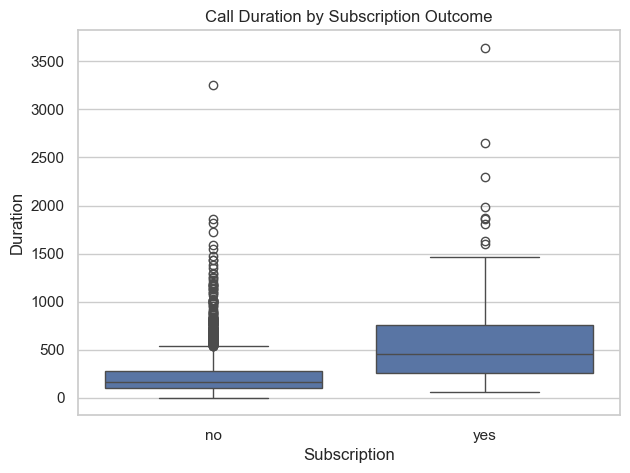

In [34]:
# Duration vs subscription
plt.figure(figsize=(7, 5))
sns.boxplot(x='y', y='duration', data=df)
plt.title("Call Duration by Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Duration")
plt.show()

- Customers who subscribed generally have longer call durations, with a higher median compared to those who did not subscribe.
- Shorter calls are mostly associated with non-subscriptions, indicating that longer conversations increase the chances of success.

### Campaign vs Subscription

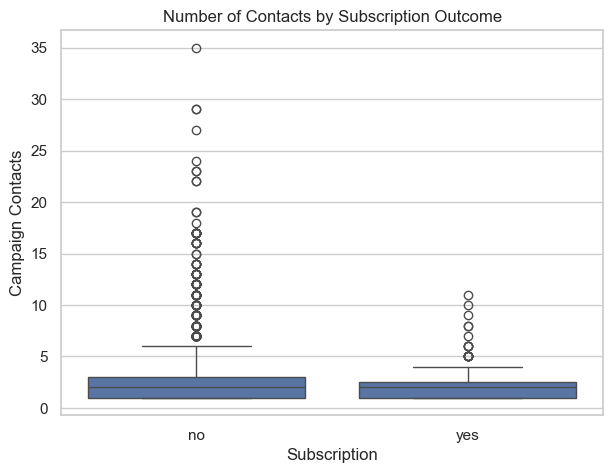

In [35]:
# 13.5 Campaign vs subscription
plt.figure(figsize=(7, 5))
sns.boxplot(x='y', y='campaign', data=df)
plt.title("Number of Contacts by Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Campaign Contacts")
plt.show()

- The number of contacts is quite similar for both subscribed and non-subscribed customers, with most values between 1 and 3.
- Increasing the number of contacts does not clearly improve subscription outcomes, as higher contact counts are mostly seen in non-subscriptions.

<a id= "three-variable"></a>
## 4.4 Three Variable Analysis

### Outliers 

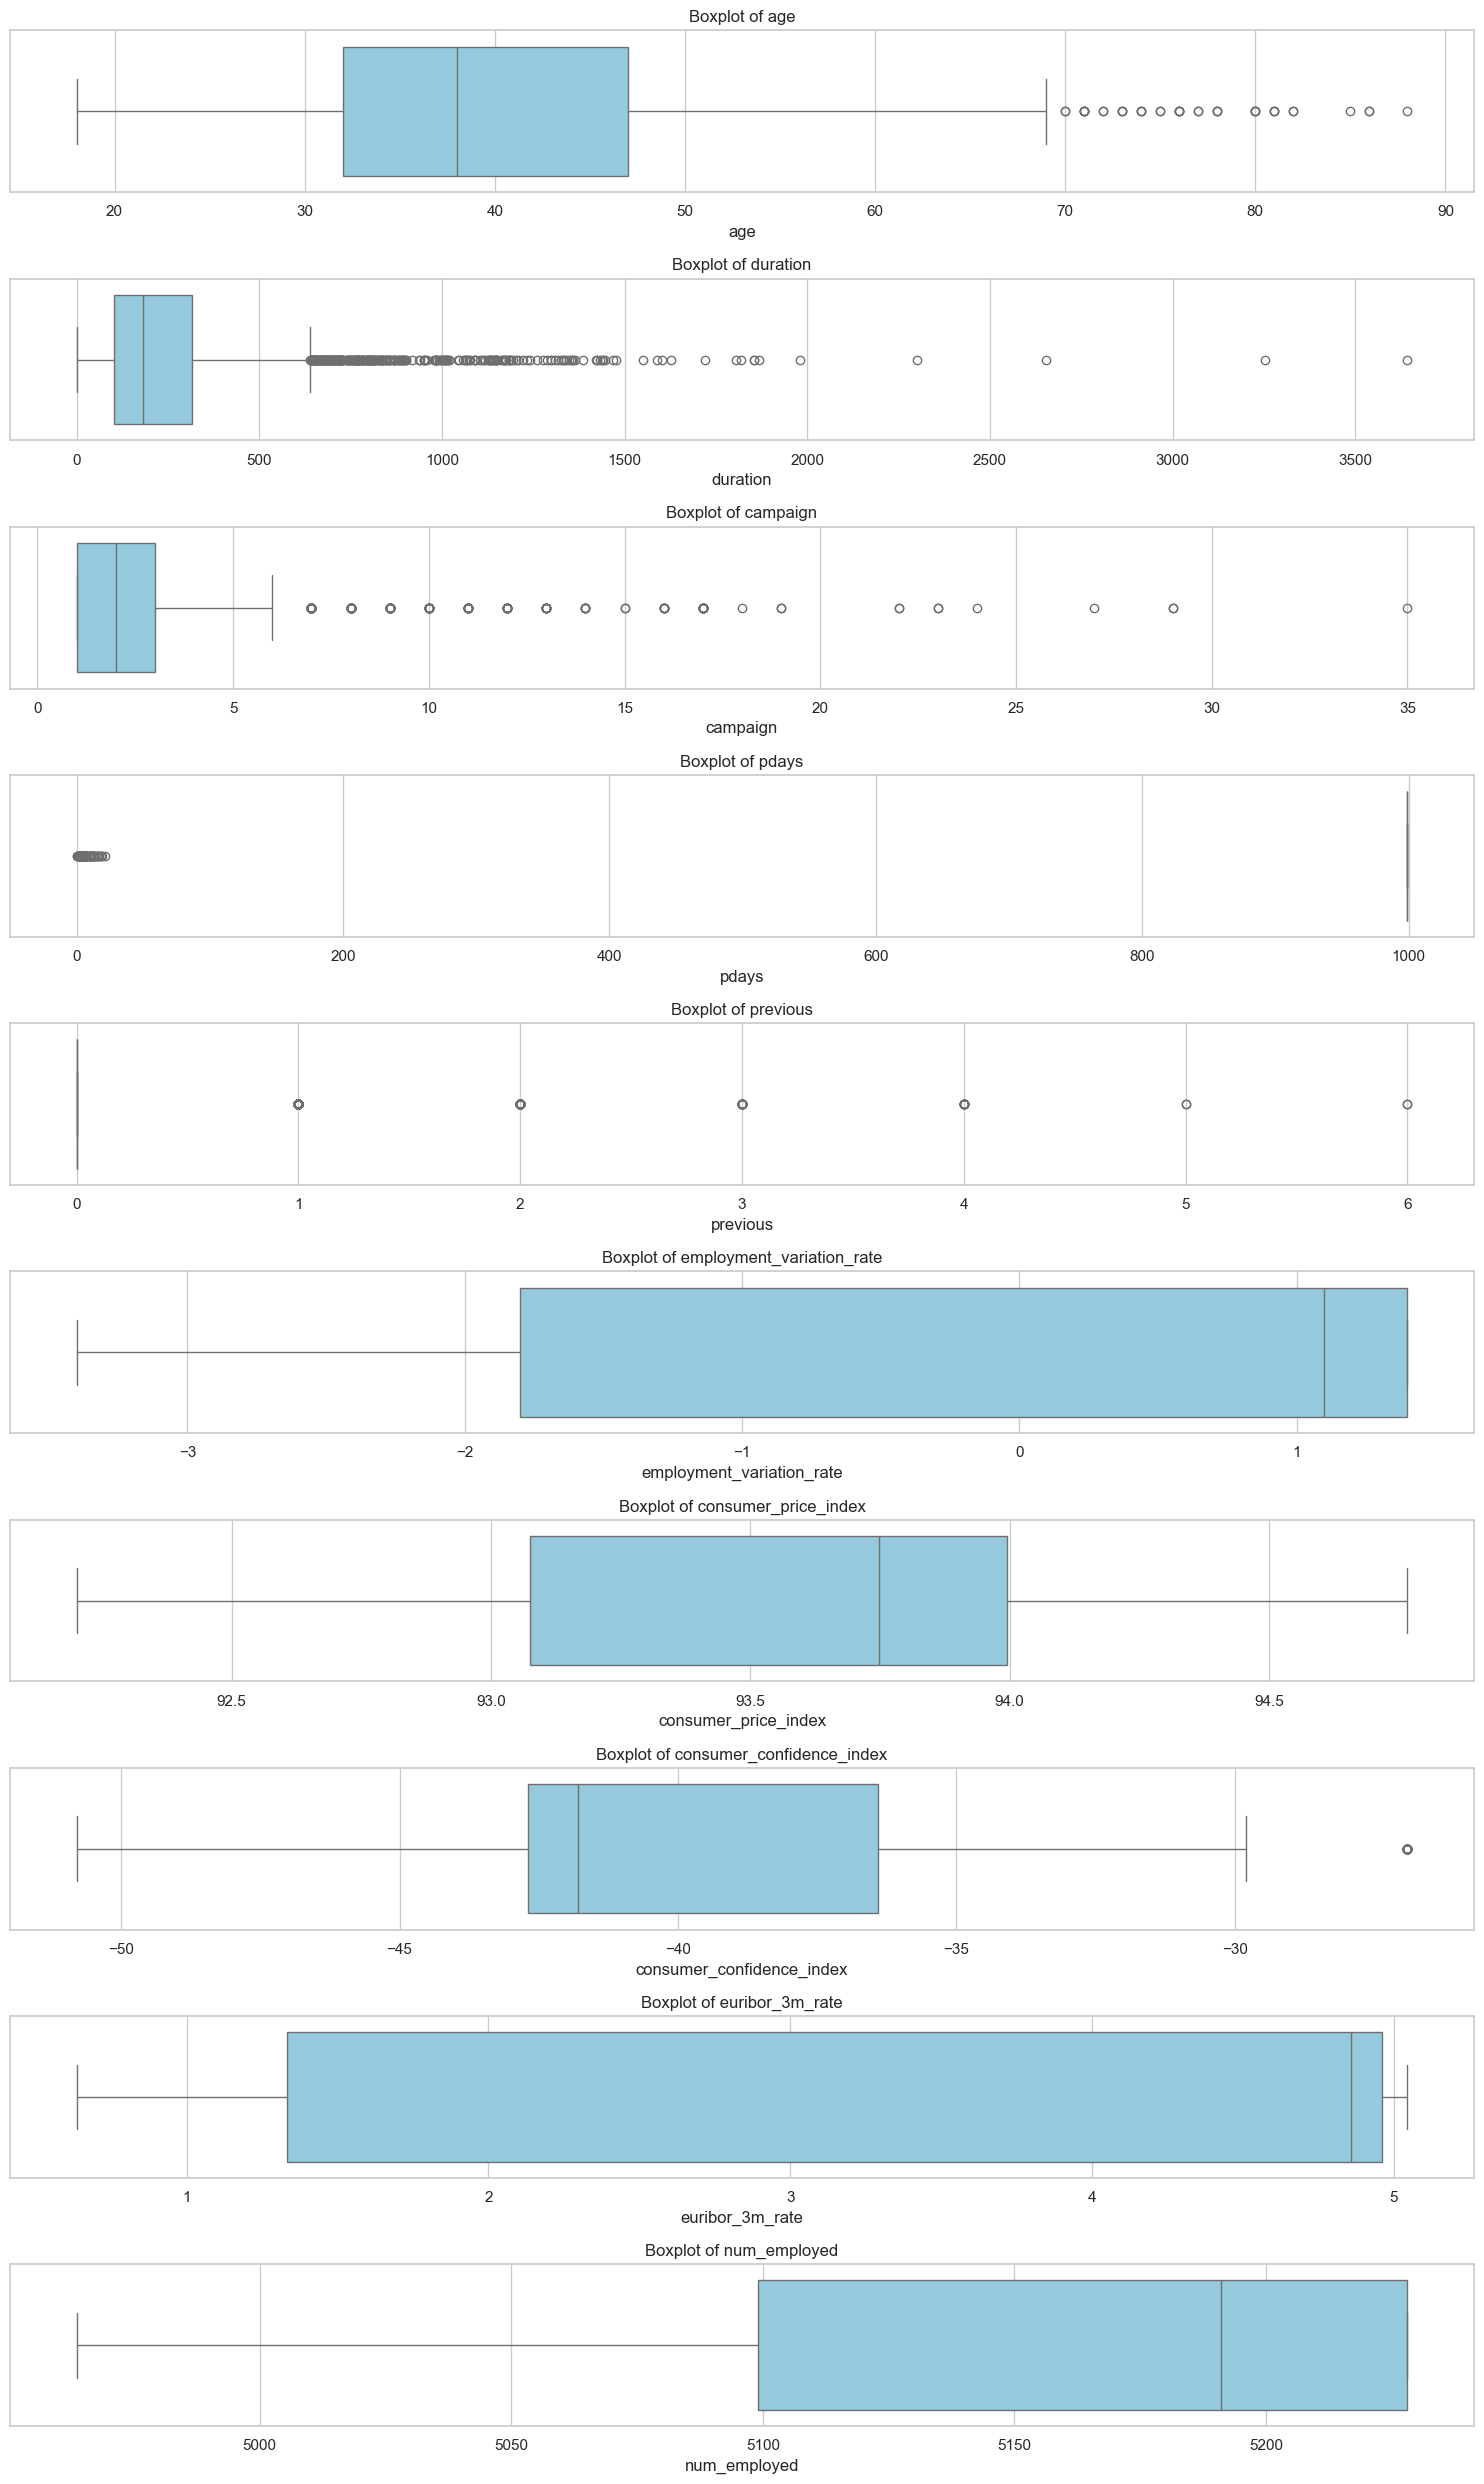

In [36]:
# Select numerical columns
num_cols = df.select_dtypes(include='number').columns

# Set up the figure
plt.figure(figsize=(15, len(num_cols)*2.5))

# Loop through each column and plot a boxplot
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

From the boxplots of numerical variables, several features show the presence of outliers. These are values that lie far from the main distribution of the data.

For example, **age** shows a few higher values above 70, but these are still realistic and represent older customers rather than data errors. Similarly, **duration** has many extreme values, with some calls lasting significantly longer than the majority. This is expected, as some customer interactions naturally take more time depending on interest and engagement.

The **campaign** variable also shows outliers, where a small number of customers were contacted many more times than others. Most customers were contacted only a few times, so these higher values stand out but still reflect real campaign behaviour.

In the case of **pdays**, a large number of values are concentrated at a specific point, indicating that many customers were not previously contacted. This creates an apparent outlier pattern, but it is actually part of the dataset’s structure rather than an anomaly.

Other variables such as **previous**, **employment variation rate**, and economic indicators show minor variations but no unusual or unrealistic values.

Overall, although outliers are present in several variables, they appear to be **valid observations** rather than errors. Therefore, no outlier removal was performed at this stage, as these values may carry important information for understanding customer behaviour.

These outliers may be particularly important for modelling, as they could indicate highly engaged or repeatedly contacted customers.

### Age vs Duration by Subscription

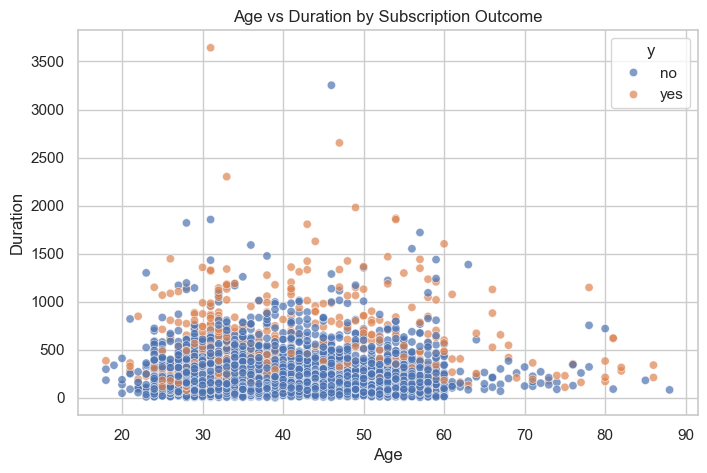

In [37]:
# Age vs duration by subscription
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='duration', hue='y', data=df, alpha=0.7)
plt.title("Age vs Duration by Subscription Outcome")
plt.xlabel("Age")
plt.ylabel("Duration")
plt.show()

- There is no strong relationship between age and call duration, as points are spread widely across all age groups.
- However, longer call durations (which are linked to subscriptions) appear across multiple age ranges, not limited to a specific group.
- This suggests age alone is not a strong predictor, but duration plays a more important role in outcomes.

### Correlation Heatmap

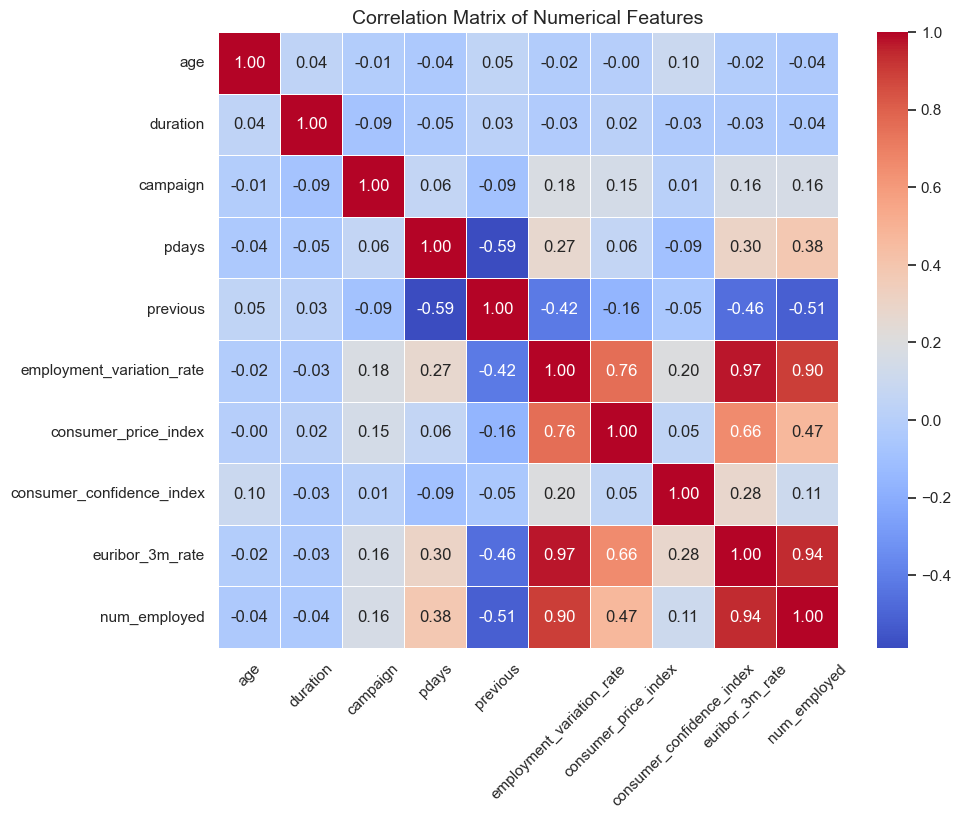

In [38]:
#  Numerical correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), 
            annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

- Strong positive correlations are observed among economic indicators such as employment variation rate, euribor 3-month rate, and number of employees, indicating they move closely together.
- There is a strong negative relationship between `pdays` and `previous`, suggesting that customers contacted recently tend to have fewer previous contacts.
- Most other variables show weak correlations, indicating low multicollinearity and that features are relatively independent for modeling.

### Pairwise Relationships of Selected Features

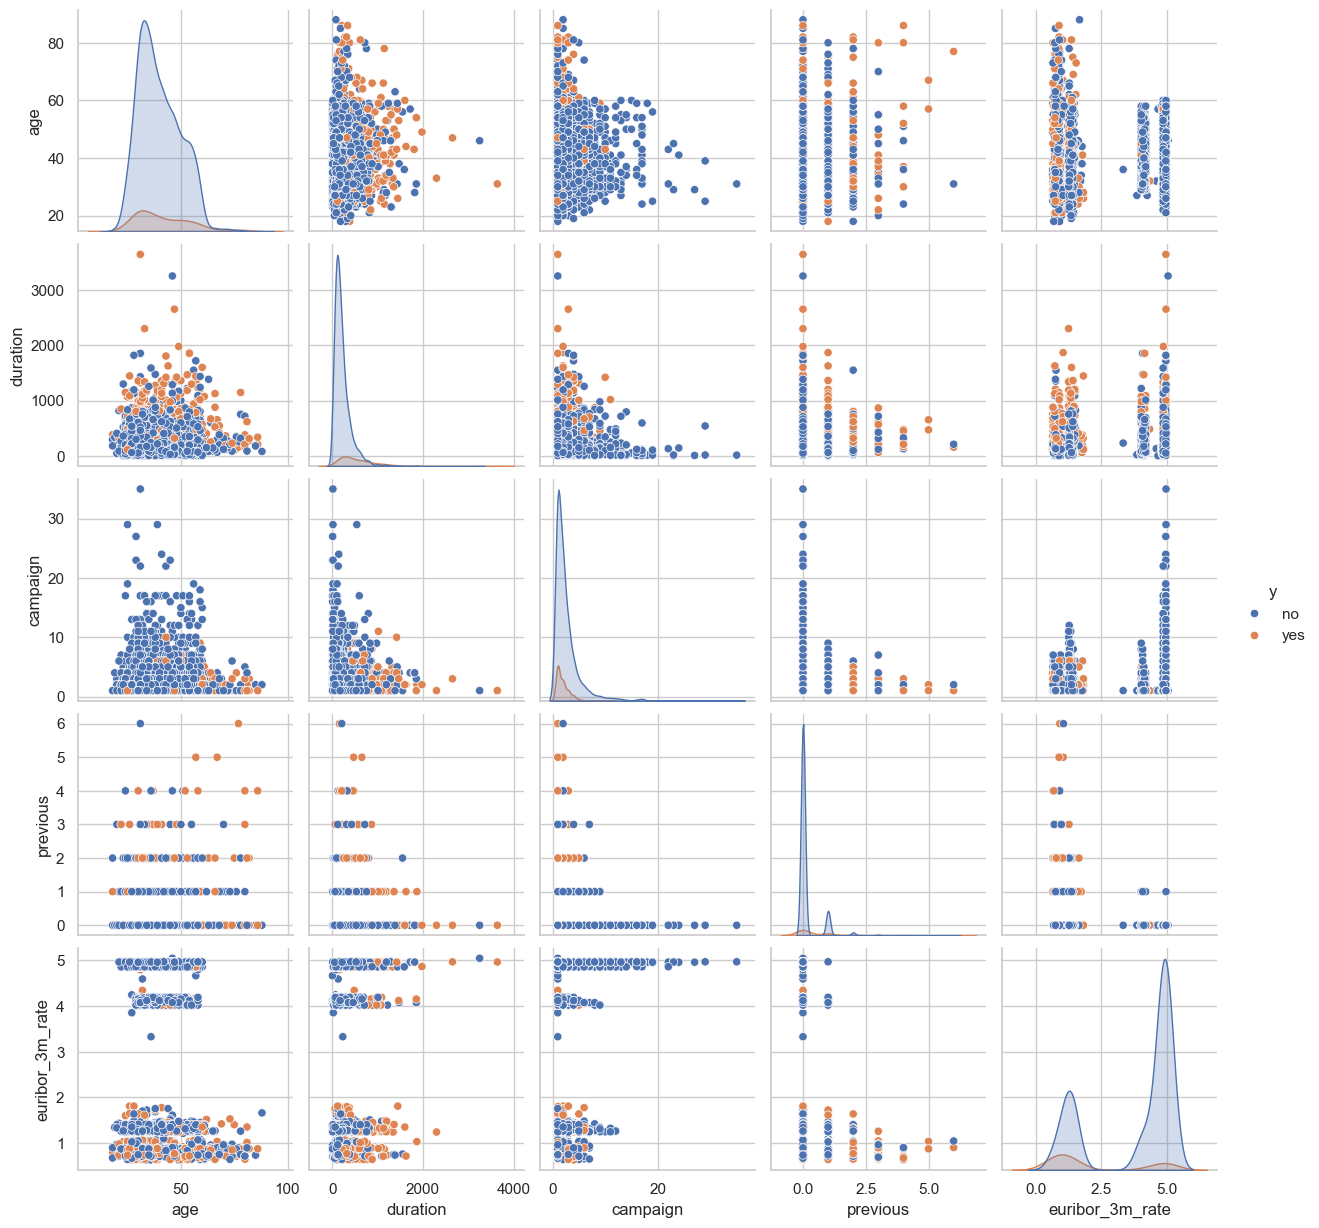

In [86]:
# Pairwise comparison of selected numeric variables
selected_num_cols = ['age', 'duration', 'campaign', 'previous', 'euribor_3m_rate']
sns.pairplot(df[selected_num_cols + ['y']], hue='y')
plt.show()


- The pairwise plots show that higher call duration is more frequently associated with successful subscriptions, with “yes” outcomes appearing more in higher duration ranges.
- Most other feature combinations (age, campaign, previous contacts) show weak or scattered relationships, indicating limited direct influence on the target when considered individually.
- There is noticeable clustering at lower campaign and previous contact values, suggesting most customers were contacted only a few times, regardless of the outcome.

### Campaign vs Duration by Subscription


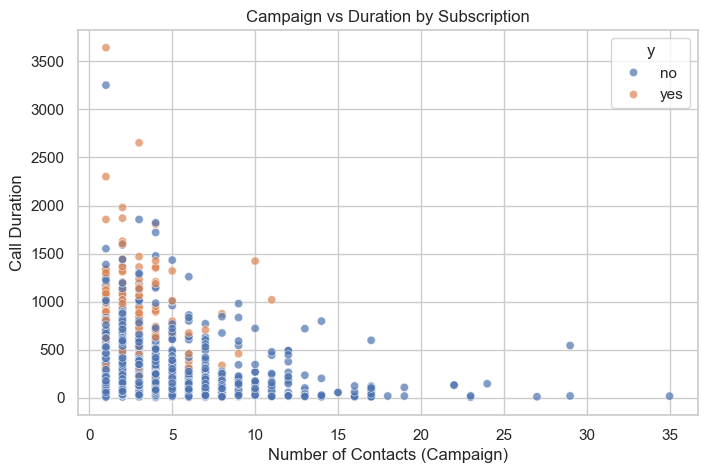

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='campaign', y='duration', hue='y', data=df, alpha=0.7)
plt.title("Campaign vs Duration by Subscription")
plt.xlabel("Number of Contacts (Campaign)")
plt.ylabel("Call Duration")
plt.show()

- Successful subscriptions (“yes”) are more concentrated at lower campaign contacts combined with higher call durations, indicating quality of interaction matters more than frequency.
- As the number of contacts increases, call duration generally decreases and the likelihood of subscription reduces, suggesting repeated contact is less effective.

### Call Duration across Months by Subscription

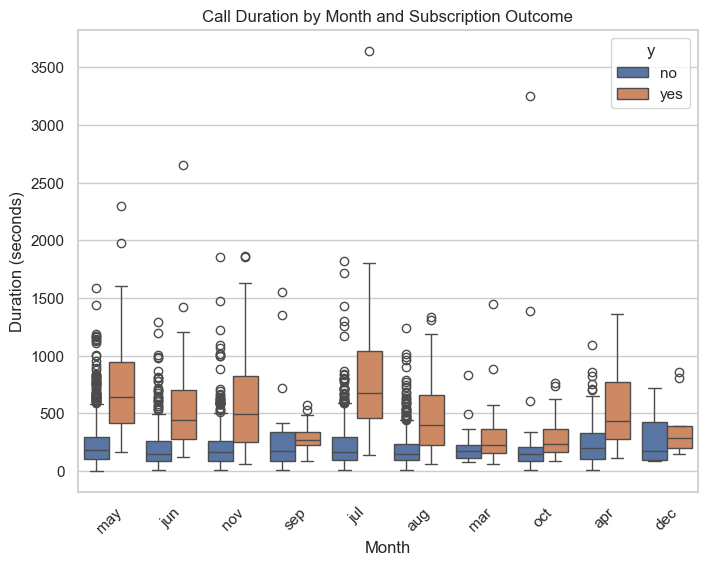

In [41]:
plt.figure(figsize=(8,6))
sns.boxplot(x='month', y='duration', hue='y', data=df)

plt.title("Call Duration by Month and Subscription Outcome")
plt.xlabel("Month")
plt.ylabel("Duration (seconds)")
plt.xticks(rotation=45)
plt.show()

- Across most months, successful subscriptions (“yes”) are associated with higher call durations compared to non-subscriptions, reinforcing the importance of longer interactions.
- There is no strong seasonal pattern in subscription success, but months like May, July, and November show slightly higher variability and longer calls.

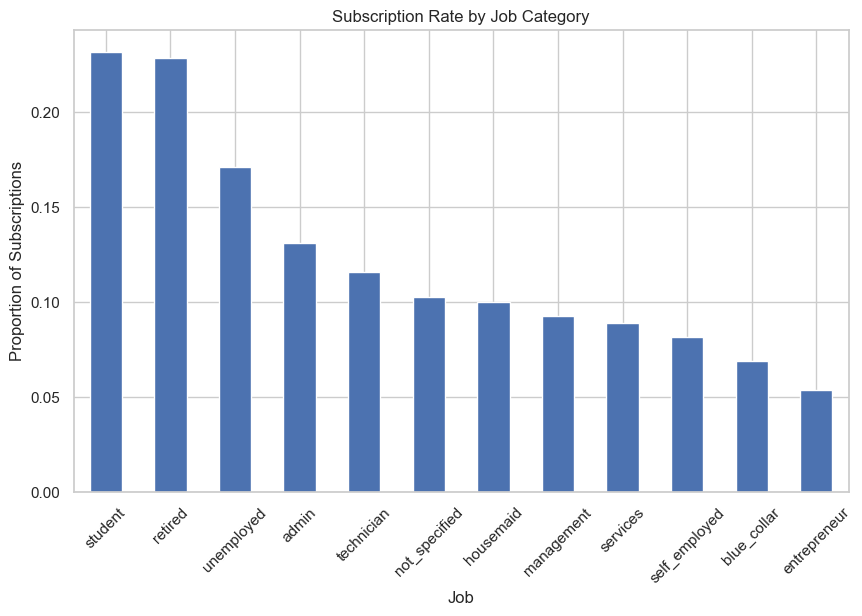

In [42]:
job_rate = df.groupby('job')['y'].value_counts(normalize=True).unstack()

plt.figure(figsize=(10,6))
job_rate['yes'].sort_values(ascending=False).plot(kind='bar')

plt.title("Subscription Rate by Job Category")
plt.ylabel("Proportion of Subscriptions")
plt.xlabel("Job")
plt.xticks(rotation=45)
plt.show()

This plot presents the proportion of successful subscriptions across different job categories, allowing for a fair comparison that accounts for differences in group sizes. 

It can be observed that certain job categories exhibit higher subscription rates, suggesting that occupation may influence responsiveness to marketing campaigns. This insight can support more targeted customer segmentation strategies.

In [43]:
for col in ['job', 'contact', 'month', 'poutcome']:
    print(f"\n--- Proportion of subscription within {col} ---")
    proportion_table = pd.crosstab(df[col], df['y'], normalize='index') * 100
    display(proportion_table.round(2))


--- Proportion of subscription within job ---


y,no,yes
job,,
admin,86.860,13.140
blue_collar,93.100,6.900
entrepreneur,94.590,5.410
housemaid,90.000,10.000
management,90.740,9.260
not_specified,89.740,10.260
retired,77.110,22.890
self_employed,91.820,8.180
services,91.090,8.910



--- Proportion of subscription within contact ---


y,no,yes
contact,,
cellular,85.860,14.140
telephone,94.820,5.180



--- Proportion of subscription within month ---


y,no,yes
month,,
apr,83.260,16.740
aug,89.940,10.060
dec,45.450,54.550
jul,91.700,8.300
jun,87.170,12.830
mar,41.670,58.330
may,93.470,6.530
nov,90.360,9.640
oct,63.770,36.230



--- Proportion of subscription within poutcome ---


y,no,yes
poutcome,,
failure,85.240,14.760
no_previous_contact,91.710,8.290
success,35.210,64.790


The multivariate analysis highlights that call duration remains a dominant factor across different months, with longer interactions consistently associated with successful outcomes. 

However, the variability across months suggests that temporal factors may also influence customer behaviour, indicating that both interaction quality (duration) and timing (month) play a role in campaign success.

## Key Insights

The exploratory analysis highlights several important factors influencing customer subscription behaviour.

Firstly, a clear class imbalance is observed, with non-subscription outcomes dominating the dataset. This has implications for model evaluation and requires careful handling in the modelling phase.

Secondly, campaign-related features, particularly call duration and contact method, show stronger relationships with subscription outcomes compared to demographic features. Longer call durations are strongly associated with successful subscriptions, although their practical use in prediction must be carefully considered.

Additionally, differences across job categories and months suggest that both customer characteristics and timing of interactions play a role in campaign effectiveness. This indicates that customer segmentation and strategic timing may improve marketing outcomes.

Overall, the exploratory analysis highlights that campaign-related features such as duration and contact method have stronger relationships with subscription outcomes compared to demographic variables. Additionally, class imbalance is evident, and temporal patterns suggest that timing also influences customer behaviour. These insights will guide feature selection and modelling decisions in Phase 2.


<a id="summary-and-conclusion"></a>
# 5. Summary & Conclusion

This phase of the project focused on preparing and understanding the bank marketing dataset to support the development of a predictive model for term deposit subscription.

The dataset was first examined and structured to ensure suitability for analysis. Key preprocessing steps included handling missing-like values, standardising categorical variables, and validating the dataset for duplicates and inconsistencies. These steps ensured that the data is clean, consistent, and reliable for further analysis without compromising its original meaning.

Exploratory data analysis provided valuable insights into the characteristics of the dataset and the relationships between features and the target variable. Campaign-related variables, particularly call duration and contact method, demonstrated stronger associations with subscription outcomes compared to demographic features. Additionally, differences across job categories and temporal factors such as month highlighted the potential importance of customer segmentation and campaign timing.

The analysis also revealed a notable class imbalance in the target variable, where non-subscription outcomes dominate. This observation is important, as it may influence model performance and requires careful consideration when selecting evaluation metrics and modelling techniques in the next phase.

Furthermore, while certain variables such as duration show strong predictive potential, their practical applicability must be evaluated, as they may not be available prior to making a prediction in a real-world setting. This highlights the importance of balancing predictive performance with real-world feasibility.

Overall, the dataset has been successfully prepared and explored, providing a clear understanding of its structure and key patterns. These findings establish a strong foundation for Phase 2, where machine learning models will be developed, evaluated, and compared to predict customer subscription behaviour effectively.

<a id="next-steps"></a>
# 6. Next Steps (Phase 2)

In the next phase, machine learning classification models will be applied to predict whether a customer will subscribe to a term deposit. Algorithms such as Logistic Regression, Decision Trees, and Random Forest will be used and compared.

Model performance will be evaluated using metrics such as accuracy, precision, recall, and F1-score. Since the dataset is imbalanced, appropriate techniques will be applied to improve prediction performance.

Based on the results, the best-performing model will be selected to identify the key factors influencing customer subscription.

<a id="literature-review"></a>
# 7. Literature Review




Moro et al studied the data from a Portuguese bank (collected between 2008 and 2013). This data had 150 features which were narrowed down to 22 most useful ones. The goal of this study was to predict how likely a customer was to subscribe to a term deposit and this was tested using a variety of methods, namely Logistic Regression, Decision Trees, Neural Networks and Support Vector Machine. These algorithms were evaluated using AUC as well as ALIFT. Among the aforementioned models, neural networks were the most effective in determining the outcome of term deposit subscription. It was also found that call duration was the most important predictor of whether a customer opted for the term deposit offered.
This is important because these findings established a benchmark for subsequent research in bank telemarketing prediction which enabled other banks to effectively make use of the data collected. It enabled the banks to identify the appropriate segment of their customer base for term deposits and helped maximise the efficacy in their marketing efforts. 

Looking at other studies done on this dataset, Borugadda et al. (2021) compared five different algorithms on the UCI Bank marketing dataset. For this comparative study, Random Forest, SVM, Gaussian Naïve Bayes, Decision Tree and Logistic Regression were used. Among this group, Logistic Regression performed the best with a 92% accuracy. Here, Asare-Frempong & Jayabalan’s (2017) work investigated predicting customer responses to bank telemarketing campaigns directly, which was built upon later in their subsequent study. Similarly, Ilham et al. (2019) conducted a comparative classification study predicting the success of bank telemarketing for long-term deposits, showing the applicability of supervised machine learning towards this problem.

Tran et al. (2023) studied customer churn prediction in banking using KNN, Random Forest, Decision Tree, Logistic Regression and SVM. Here feature selection was used to identify the important predictors for customer churn. Its findings indicate that the two best training methods are random forest and support vector machines and discovered that customer segmentation has no impact on the ability to anticipate customer attrition.
Mouli et al. (2024) evaluated ten classification algorithms including LR, SVM, KNN using K fold cross validation to assess performance. This study had a wider range of algorithms used but found that no single algorithm dominated across all metrics, highlighting the importance of a varied method of analysis in order to derive a more concrete picture of the outcome.

 In a comparative study about ensemble methods, Luo et al. (2022) built hybrid ensemble methods and found that hybrid RS-MB approach performed the best while customer job type, month of contact and day of week were the key predictors.  Peter et al. (2025) evaluated bagging, boosting and stacking ensemble methods and found that stacking performed the best - with a 91.88% accuracy and with an AUC of 0.9491. When comparing multiple classifiers Du (2025) found that gradient boosting outperformed traditional models.
These studies varied in their usage of algorithms and commonly used more than one algorithm and found that different algorithms performed best in their own setting, highlighting the importance of a comparative algorithmic study. This project adopts this approach by evaluating multiple algorithms on the bank marketing dataset. 

The choice of algorithm is a critical consideration in any classification problem. Couronne et al. (2018) conducted a large scale benchmark study comparing Random Forest and Logistic Regression across 243 real datasets, finding that Random Forest outperformed Logistic Regression in approximately 69% of cases. Though it cannot be definitively concluded that LR should be the go to model for analysis, as mentioned earlier, this highlights the importance of comparing multiple algorithms rather than relying on a single approach. Patil et al. (2022) similarly compared Decision Tree, KNN, SVM and Logistic Regression for customer prediction in banking and telecom sectors, finding that performance varied meaningfully depending on dataset characteristics. Model performance in these studies was commonly evaluated using the Area Under the ROC Curve (AUC), a metric shown to be effective for comparing classifier performance across varying thresholds (Bradley, 1997)

The bank marketing dataset has more ‘no’ compared to ‘yes’  meaning there is a considerable class imbalance in the dataset. In this case models tend to be biased toward predicting the majority class. Chawla et al. (2002) introduced SMOTE which creates synthetic minority examples instead of replicating the yes responses and Pradipta et al. (2021) reviewed SMOTE and its applications and confirmed its effectiveness. 
Abdelhamid & Desai (2024) compared three strategies – SMOTE, class weights, decision threshold calibration, and found decision threshold calibration to be the most effective. Class weights instruct the model to penalise mistakes on the minority class heavily and the decision threshold calibration adjusts the cutoff where the model predicts yes. This is again relevant because of the class imbalance in the bank marketing dataset.

We can see that current research shows machine learning as a proven approach for predicting customer behaviour in banking. As well as proving that algorithm choice, handling of class imbalance, and feature selection are all important in model performance. Though there’s not a single go to model, basic models such as logistic regression are a strong start against which more complex approaches are compared. This project builds on the above findings by preparing the bank marketing dataset for predictive modelling for the comparison of multiple classification algorithms in Phase 2.

<a id="references"></a>

# 8. References:


Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306.

Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. Decision Support Systems, 62, 22-31

Bradley, A. P. (1997).  The Use of the Area Under the ROC Curve in the Evaluation of Machine Learning Algorithms. Pattern Recognition,30(6), 1145–1159

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. Journal of Artificial Intelligence Research, 16, 321–357.

Couronné, R., Probst, P., & Boulesteix, A. L. (2018). Random forest versus logistic regression: A large-scale benchmark experiment. BMC Bioinformatics, 19, 270.

Du, S. (2025). Findings from the bank marketing dataset: Using machine learning to forecast term deposit subscriptions. Advances in Economics, Management and Political Sciences, 240, 60–69.

Abdelhamid, M., & Desai, A. (2024). Balancing the scales: A comprehensive study on tackling class imbalance in binary classification. arXiv preprint arXiv:2409.19751. 

Borugadda, P., Nandru, P., & Madhavaiah, C. (2021). Predicting the success of bank telemarketing for selling long-term deposits: An application of machine learning algorithms. St. Theresa Journal of Humanities and Social Sciences, 7(1), 91-108.

Xie, C., Zhang, J. L., Zhu, Y., Xiong, B., & Wang, G. J. (2023). How to improve the success of bank telemarketing? Prediction and interpretability analysis based on machine learning. Computers & Industrial Engineering, 175, 108874.

Mouli, K. C., Raghavendran, C. V., Bharadwaj, V. Y., Vybhavi, G. Y., Sravani, C., Vafaeva, K. M., ... & Hussein, L. (2024). An analysis on classification models for customer churn prediction. Cogent Engineering, 11(1), 2378877

Peter, M., Mofi, H., Likoko, S., Sabas, J., Mbura, R., & Mduma, N. (2025). Predicting customer subscription in bank telemarketing campaigns using ensemble learning models. Machine Learning with Applications, 19, 100618

Tran, H. D., Le, N., & Nguyen, V. H. (2023). Customer churn prediction in the banking sector using machine learning-based classification models. Interdisciplinary Journal of Information, Knowledge, and Management, 18, 87–105.

Asare-Frempong, J., & Jayabalan, M. (2017, September). Predicting customer response to bank direct telemarketing campaign. In 2017 International Conference on Engineering Technology and Technopreneurship (ICE2T) (pp. 1-4). IEEE.

Ilham, A., Khikmah, L., Indra, Ulumuddin, & Bagus Ary Indra Iswara, I. (2019, March). Long-term deposits prediction: a comparative framework of classification model for predict the success of bank telemarketing. In Journal of Physics: Conference Series (Vol. 1175, No. 1, p. 012035). IOP Publishing.

Patil, K., Patil, S., Danve, R., & Patil, R. (2022, February). Machine learning and neural network models for customer churn prediction in banking and telecom sectors. In Proceedings of Second International Conference on Advances in Computer Engineering and Communication Systems: ICACECS 2021 (pp. 241-253). Singapore: Springer Nature Singapore.

Pradipta, G. A., Wardoyo, R., Musdholifah, A., Sanjaya, I. N. H., & Ismail, M. (2021, November). SMOTE for handling imbalanced data problem: A review. In 2021 sixth international conference on informatics and computing (ICIC) (pp. 1-8). IEEE
